# What Makes Teams Win?

This project explores match statistics from the FIFA World Cup to identify the characteristics associated with winning teams.

Through exploratory data analysis (EDA), feature engineering, and correlation analysis, the project investigates which performance indicators are most closely related to match outcomes.

In [86]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/wasiqaliyasir/fifa-match-player-and-team-dataset-2026/players.csv
/kaggle/input/datasets/wasiqaliyasir/fifa-match-player-and-team-dataset-2026/matches.csv
/kaggle/input/datasets/wasiqaliyasir/fifa-match-player-and-team-dataset-2026/teams.csv


Import the dataset

In [87]:
import pandas as pd
df = pd.read_csv(r"/kaggle/input/datasets/wasiqaliyasir/fifa-match-player-and-team-dataset-2026/matches.csv")
print(df.head())
print(df.info())
print(df.describe())

df.isnull().sum()

df[df["notes"].isnull()]

         round  gameweek dayofweek        date start_time       home_team  \
0  Group stage         1       Thu  2026-06-11      13:00          Mexico   
1  Group stage         1       Thu  2026-06-11      20:00  Korea Republic   
2  Group stage         1       Fri  2026-06-12      15:00          Canada   
3  Group stage         1       Fri  2026-06-12      18:00   United States   
4  Group stage         1       Sat  2026-06-13      12:00           Qatar   

        away_team score  home_score  away_score  ... away_fouls home_corners  \
0    South Africa   2–0           2           0  ...         11            3   
1         Czechia   2–1           2           1  ...         16            4   
2  Bosnia & Herz.   1–1           1           1  ...         20            9   
3        Paraguay   4–1           4           1  ...         17            3   
4     Switzerland   1–1           1           1  ...         11            3   

  away_corners home_crosses away_crosses home_intercepti

,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,...,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2,0,...,11,3,1,12,8,8,7,1.0,1.0,NaN
1,Group stage,1,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2,1,...,16,4,5,12,15,11,7,2.0,2.0,NaN
2,Group stage,1,Fri,2026-06-12,15:00,Canada,Bosnia & Herz.,1–1,1,1,...,20,9,4,24,10,4,10,1.0,0.0,NaN
3,Group stage,1,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4,1,...,17,3,1,17,5,11,9,2.0,1.0,NaN
4,Group stage,1,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1,1,...,11,3,10,8,35,10,7,0.0,1.0,NaN
5,Group stage,1,Sat,2026-06-13,18:00,Brazil,Morocco,1–1,1,1,...,14,6,2,16,15,5,4,0.0,1.0,NaN
6,Group stage,1,Sat,2026-06-13,21:00,Haiti,Scotland,0–1,0,1,...,21,4,3,23,14,6,6,3.0,1.0,NaN
7,Group stage,1,Sat,2026-06-13,21:00,Australia,Türkiye,2–0,2,0,...,4,5,8,14,26,6,4,1.0,3.0,NaN
8,Group stage,1,Sun,2026-06-14,12:00,Germany,Curaçao,7–1,7,1,...,11,8,1,12,7,10,16,0.0,1.0,NaN
9,Group stage,1,Sun,2026-06-14,15:00,Netherlands,Japan,2–2,2,2,...,7,5,4,21,23,7,4,1.0,0.0,NaN


In [88]:
#Save all the plot
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

counter = 1

original_show = plt.show


def save_show(*args, **kwargs):
    global counter
    
    plt.savefig(
        f"images/{counter:02d}_figure.png",
        dpi=300,
        bbox_inches="tight"
    )
    
    counter += 1
    
    original_show(*args, **kwargs)


plt.show = save_show

Giving some basic information about the data and columns but also found the null value

In [89]:
# Found two NaN values in offside categories in one match 
df[df["home_offsides"].isnull()]
df[df["away_offsides"].isnull()]
df = df.dropna(subset=["home_offsides", "away_offsides"])

Checking the null values and droping them

In [90]:
#Definition of home result - win
df["home_result"] = "Draw"

df.loc[df["home_score"] > df["away_score"], "home_result"] = "Win"
df.loc[df["home_score"] < df["away_score"], "home_result"] = "Lose"

df["home_result"].value_counts()

print(df.columns)
print(df["home_result"].value_counts())


Index(['round', 'gameweek', 'dayofweek', 'date', 'start_time', 'home_team',
       'away_team', 'score', 'home_score', 'away_score', 'attendance', 'venue',
       'referee', 'home_formation', 'away_formation', 'home_manager',
       'away_manager', 'home_captain', 'away_captain', 'home_possession',
       'away_possession', 'home_sot', 'away_sot', 'home_total_shots',
       'away_total_shots', 'home_saves', 'away_saves', 'home_cards_yellow',
       'away_cards_yellow', 'home_cards_red', 'away_cards_red', 'home_fouls',
       'away_fouls', 'home_corners', 'away_corners', 'home_crosses',
       'away_crosses', 'home_interceptions', 'away_interceptions',
       'home_offsides', 'away_offsides', 'notes', 'home_result'],
      dtype='object')
home_result
Win     9
Draw    8
Lose    2
Name: count, dtype: int64


We don't have the results yet, so we make a definition of results: Win, Lose and Draw.

We first investigate whether ball possession is associated with match outcomes.

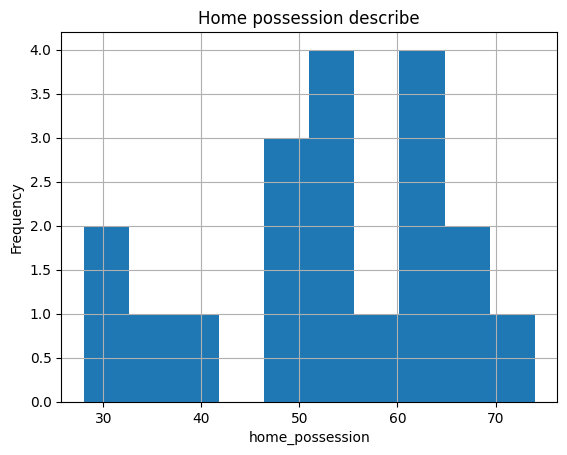

In [91]:
#Distribution of Home Team Possession; Frequency of Possession Rates for Winning Teams
df["home_possession"].describe()

import matplotlib.pyplot as plt
df["home_possession"].hist(bins=10) 
plt.title("Home possession describe") 
plt.xlabel("home_possession") 
plt.ylabel("Frequency")
plt.show()

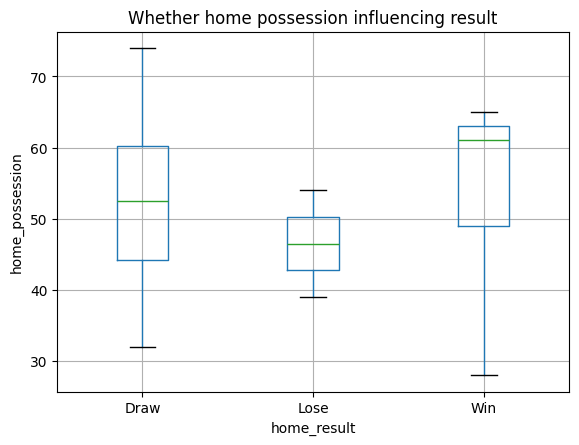

In [92]:
# Group the results, examine the distribution of average ball possession rates, and create a plot.
df["home_possession"].describe()


#主队控球率是否决定输赢
df.groupby("home_result")["home_possession"].mean()

#Graphics
import matplotlib.pyplot as plt

df.boxplot( column="home_possession", by="home_result" ) 
plt.title("Whether home possession influencing result") 
plt.suptitle("") 
plt.xlabel("home_result") 
plt.ylabel("home_possession") 
plt.show()



Winning teams recorded the highest average possession (54.3%), while losing teams averaged only 46.5%. This suggests that maintaining possession may contribute to match success.

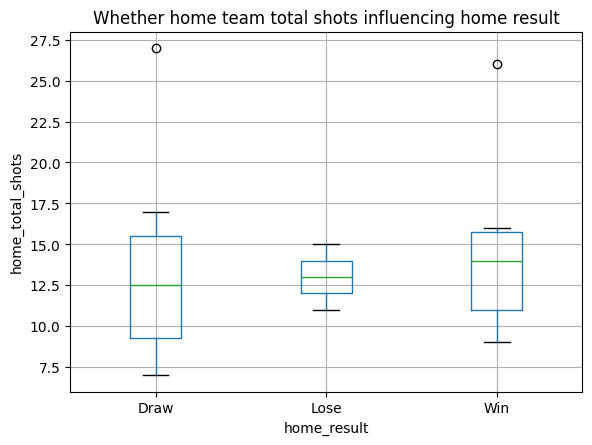

In [93]:
#Group the results, calculate the average number of shots, and plot the data.
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"/kaggle/input/datasets/wasiqaliyasir/fifa-match-player-and-team-dataset-2026/matches.csv")


#Definiation of win
df["home_result"] = "Draw"

df.loc[df["home_score"] > df["away_score"], "home_result"] = "Win"
df.loc[df["home_score"] < df["away_score"], "home_result"] = "Lose"

df["home_result"].value_counts()

#主队射门数量是否决定输赢
df.groupby("home_result")["home_total_shots"].mean()


df.boxplot(column="home_total_shots", by="home_result" ) 
plt.title("Whether home team total shots influencing home result") 
plt.suptitle("") 
plt.xlabel("home_result") 
plt.ylabel("home_total_shots") 
plt.show()

Lose and Draw only have a 0.5 difference in home team total shots, while the Win result is as high as 14.2

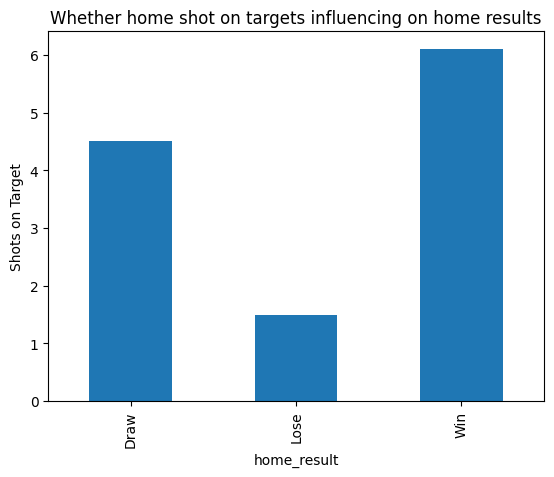

In [94]:
#Group the results, calculate the average number of Shots on Target, and plot the data.
df.groupby("home_result")["home_sot"].mean()


summary_1["Shots on Target"].plot(kind="bar") 

plt.title("Whether home shot on targets influencing on home results") 
plt.xlabel("home_result") 
plt.ylabel("Shots on Target") 

plt.show()



On this shots-on-target indicator, we can see a clear trend. Losses only have 1.5 SOT, draws have 4.5 SOT but wins remain high, like 6.1. It will be an important factor to analyse

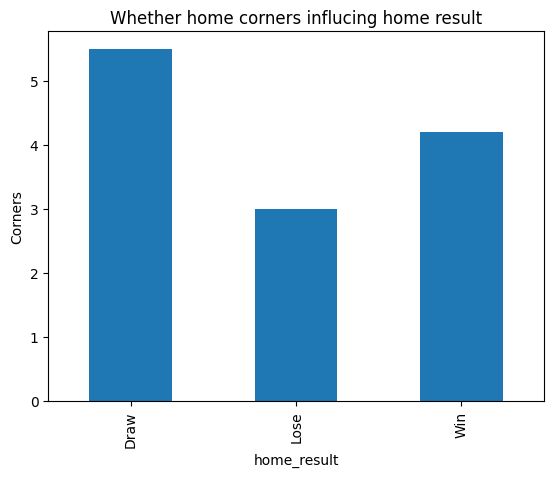

In [95]:
#Group the results, calculate the average number of corner kicks, and plot the data.
df.groupby("home_result")["home_corners"].mean()


summary_1["Corners"].plot(kind="bar")  
plt.title("Whether home corners influcing home result") 
plt.xlabel("home_result") 
plt.ylabel("Corners") 

plt.show()



Surprisingly, Win(4.2 corners) is on the middle of Draw(5.5 corners) and Lose(3 corners)

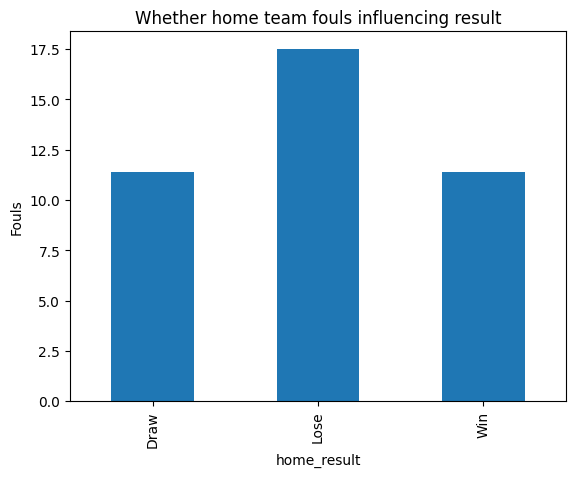

In [96]:
#Group the results, calculate the average number of fouls, and plot the data.
df.groupby("home_result")["home_fouls"].mean()


summary_1 ["Fouls"].plot(kind="bar") 

plt.title("Whether home team fouls influencing result") 
plt.xlabel("home_result") 
plt.ylabel("Fouls") 

plt.show()

The Lose team has many more fouls (17.5) than the Draw (11.375) and Win(11.4) matches.

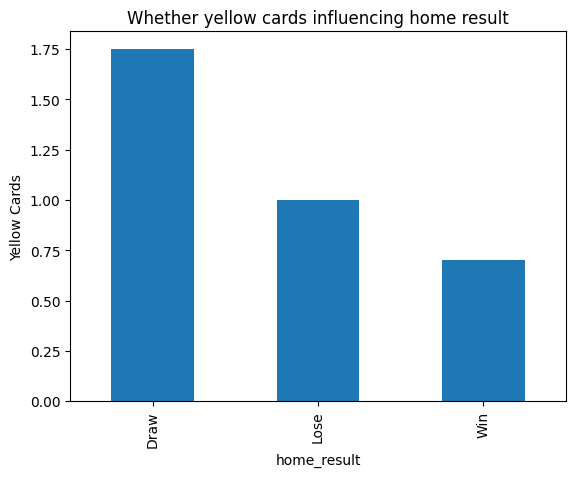

In [97]:
#Group the results, calculate the average number of yellow cards, and plot the data.
df.groupby("home_result")["home_cards_yellow"].mean()

summary_1 ["Yellow Cards"].plot(kind="bar")

plt.title("Whether yellow cards influencing home result") 
plt.xlabel("home_result") 
plt.ylabel("Yellow Cards") 

plt.show()


Draw team has 1.75 yellow cards, while the Lose team only have 1 and the Win team is still as low as 0.7

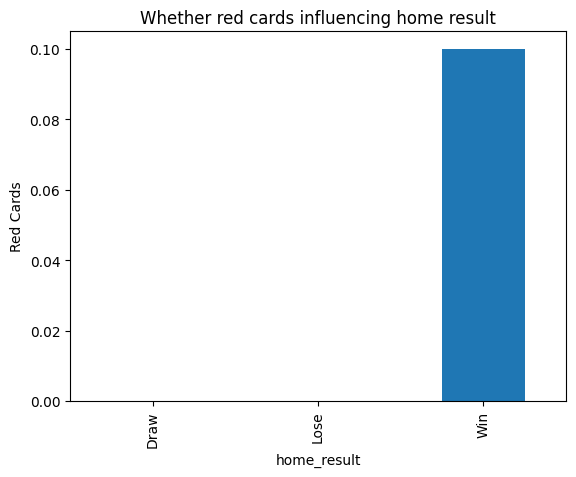

In [98]:
#Group the results, calculate the average number of red cards, and plot the data.
df.groupby("home_result")["home_cards_red"].mean()

summary_1 ["Red Cards"].plot(kind="bar")

plt.title("Whether red cards influencing home result") 
plt.xlabel("home_result") 
plt.ylabel("Red Cards") 

plt.show()

Red cards seldom appeared in the data so the red card won't be useful to analyse

In [99]:
#Summary_1
summary_1 = pd.DataFrame({
    "Possession": df.groupby("home_result")["home_possession"].mean(),
    "Shots": df.groupby("home_result")["home_total_shots"].mean(),
    "Shots on Target": df.groupby("home_result")["home_sot"].mean(),
    "Corners": df.groupby("home_result")["home_corners"].mean(),
    "Fouls": df.groupby("home_result")["home_fouls"].mean(),
    "Yellow Cards": df.groupby("home_result")["home_cards_yellow"].mean(),
    "Red Cards": df.groupby("home_result")["home_cards_red"].mean() })

summary_1


,Possession,Shots,Shots on Target,Corners,Fouls,Yellow Cards,Red Cards
home_result,,,,,,,
Draw,51.625,13.5,4.5,5.5,11.375,1.75,0.0
Lose,46.500,13.0,1.5,3.0,17.500,1.00,0.0
Win,54.300,14.2,6.1,4.2,11.400,0.70,0.1


Reviewing all factors above

In [100]:
#Difference between winning results and losing results
difference = pd.DataFrame({"Difference": summary_1.loc["Win"] - summary_1.loc["Lose"]})

difference = summary_1.loc["Win"] - summary_1.loc["Lose"]


difference

Possession         7.8
Shots              1.2
Shots on Target    4.6
Corners            1.2
Fouls             -6.1
Yellow Cards      -0.3
Red Cards          0.1
dtype: float64

Looking at the differences

In [101]:
#Percentage of degree of difference between winning results and losing results
relative = pd.DataFrame({"Relative Difference (%)":(summary_1.loc["Win"] - summary_1.loc["Lose"])/ summary_1.loc["Lose"] * 100})
relative

,Relative Difference (%)
Possession,16.774194
Shots,9.230769
Shots on Target,306.666667
Corners,40.000000
Fouls,-34.857143
Yellow Cards,-30.000000
Red Cards,inf


Considering different factors have different units, % will be useful and fair to compare

In [102]:
# Summary_2 
summary_2= pd.DataFrame({

    "Win":
        summary_1.loc["Win"],

    "Draw":
        summary_1.loc["Draw"],

    "Lose":
        summary_1.loc["Lose"],

    "Difference":
        summary_1.loc["Win"] -
        summary_1.loc["Lose"],

    "Relative Difference (%)":
        (
            summary_1.loc["Win"] -
            summary_1.loc["Lose"]
        )
        /
        summary_1.loc["Lose"]
        *100
})

summary_2

,Win,Draw,Lose,Difference,Relative Difference (%)
Possession,54.3,51.625,46.5,7.8,16.774194
Shots,14.2,13.500,13.0,1.2,9.230769
Shots on Target,6.1,4.500,1.5,4.6,306.666667
Corners,4.2,5.500,3.0,1.2,40.000000
Fouls,11.4,11.375,17.5,-6.1,-34.857143
Yellow Cards,0.7,1.750,1.0,-0.3,-30.000000
Red Cards,0.1,0.000,0.0,0.1,inf


Putting differences into the summary table

In [103]:
# Average Possession, Shots, shots on target, corner kicks, fouls, yellow cards, correlation analysis.
df[["home_possession","home_total_shots","home_sot","home_corners","home_fouls","home_cards_yellow"]].corr()

,home_possession,home_total_shots,home_sot,home_corners,home_fouls,home_cards_yellow
home_possession,1.000000,0.705762,0.474043,0.474132,0.006633,0.058339
home_total_shots,0.705762,1.000000,0.522049,0.551796,0.234878,-0.144279
home_sot,0.474043,0.522049,1.000000,0.502750,-0.134840,-0.374994
home_corners,0.474132,0.551796,0.502750,1.000000,-0.101686,-0.065985
home_fouls,0.006633,0.234878,-0.134840,-0.101686,1.000000,-0.101392
home_cards_yellow,0.058339,-0.144279,-0.374994,-0.065985,-0.101392,1.000000


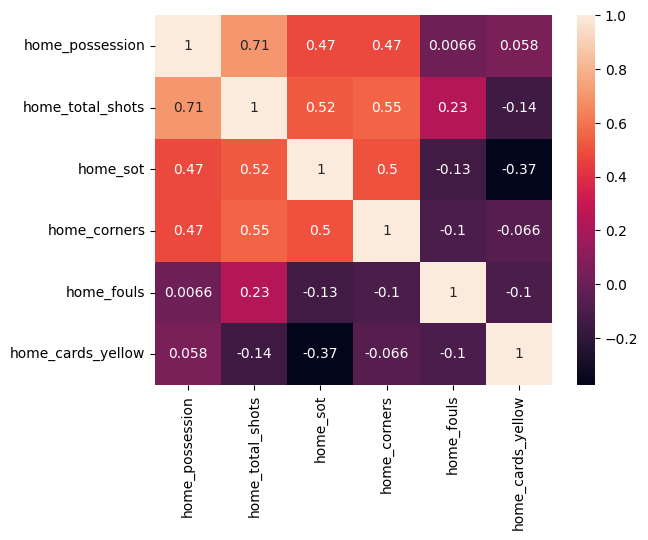

In [104]:
# Average Possession, Shots, Shots on Target, Corner Kicks, Fouls, Yellow Cards, Correlation Analysis, Heatmap
import seaborn as sns 
import matplotlib.pyplot as plt

corr = df[["home_possession","home_total_shots","home_sot","home_corners","home_fouls","home_cards_yellow"]].corr()

sns.heatmap( corr, annot=True ) 
plt.show()


We can see that possessions and total shots have a strong correlation through the heat map, with the highest value of 0.71. More shots with more corners is 0.552, and they are related. Shots on target and corners have the same amount as possession and both are 0.47.

# Key Findings

1. Winning teams generally maintained higher possession.

2. Shots on target showed the largest difference between winning and losing teams.

3. Losing teams committed substantially more fouls.

4. Shot accuracy and goal conversion were strongly positively correlated.

5. Corner efficiency appeared to have limited association with overall attacking effectiveness.

# Conclusion 1:

This analysis suggests that winning is associated more with creating accurate shooting opportunities than merely increasing shot volume. Teams with higher possession also tended to generate more shots. Meanwhile, disciplinary statistics such as yellow cards appeared to have weaker relationships with match outcomes.

# **Feature Engineering**

In addition to the original match statistics, four new performance metrics were created to better evaluate attacking efficiency. These engineered features aim to provide more meaningful insights than raw statistics alone.

**Shot Accuracy**

Shot Accuracy measures the proportion of total shots that were on target.# 

Formula:

Shots on Target / Total Shots

Higher values indicate better shooting precision.

<Axes: xlabel='home_result'>

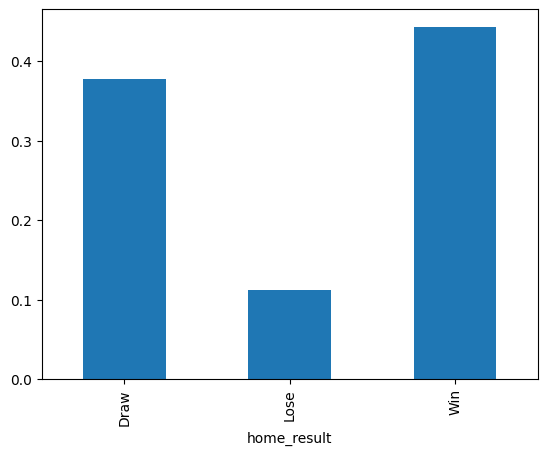

In [105]:
# New variable - shot accuracy rate
df["shot_accuracy"] = (df["home_sot"] / df["home_total_shots"])

#Does shot accuracy influence match results? Feature Engineering（特征工程）
df.groupby("home_result")["shot_accuracy"].mean()

#Graphics Bar Chart
df.groupby("home_result")["shot_accuracy"].mean().plot(kind="bar")


**Goal Conversion Rate**
 
Goal Conversion Rate measures how efficiently shots were converted into goals.

Formula:

Goals / Total Shots

Higher values indicate more efficient finishing.

<Axes: xlabel='home_result'>

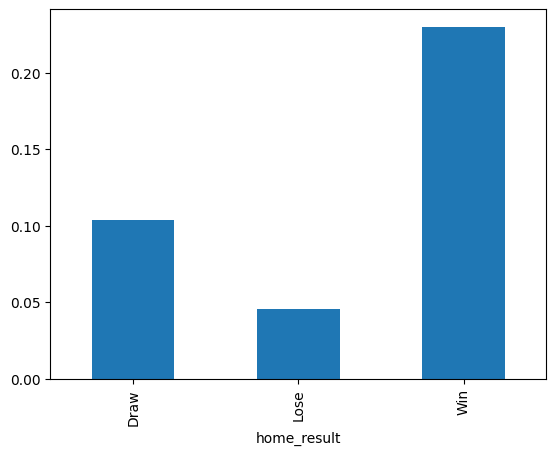

In [106]:
# New variable - goal conversion rate
df["goal_conversion"] = (df["home_score"] / df["home_total_shots"])

#Does goal conversion influence match results? 
df.groupby("home_result")["goal_conversion"].mean()

df.groupby("home_result")["goal_conversion"].mean().plot(kind="bar")

**Shots per Possession**

This metric measures how efficiently a team turns ball possession into shooting opportunities.

Formula:

Total Shots / Possession

Higher values indicate more direct attacking play.

<Axes: xlabel='home_result'>

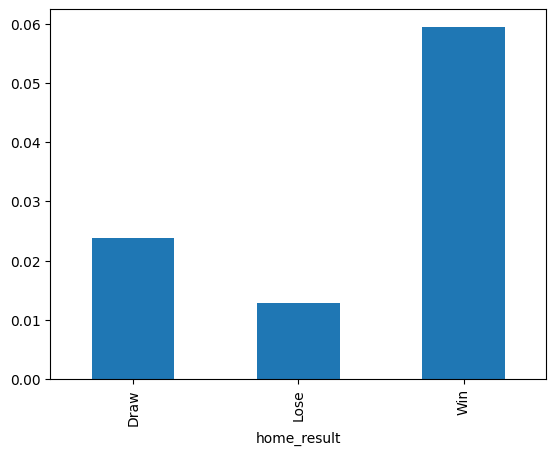

In [107]:
# New variable - shots per possessions
df["shots_per_possessions"] = (df["home_score"] / df["home_possession"])

#Does goal conversion influence match results? 
df.groupby("home_result")["shots_per_possessions"].mean()

df.groupby("home_result")["shots_per_possessions"].mean().plot(kind="bar")

**Shots per Corners**

This metric measures how many shots are generated from each corner opportunity.

Formula:

Total Shots / Corners

Higher values may indicate better use of set-piece opportunities.

<Axes: xlabel='home_result'>

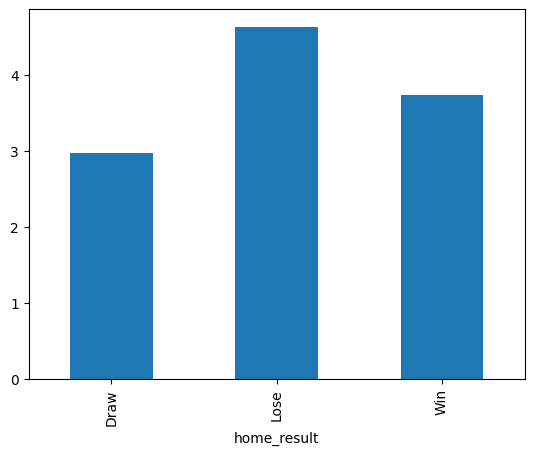

In [108]:
# New variable - shots per corners
df["shots_per_corner"] = (
    df["home_total_shots"] /
    df["home_corners"]
)

#Does shots per corners influence match results? 
df.groupby("home_result")["shots_per_corner"].mean()

df.groupby("home_result")["shots_per_corner"].mean().plot(kind="bar")

In [109]:
# Summary_3 
summary_3= pd.DataFrame({ "Win":
        summary_1.loc["Win"],

    "Draw":
        summary_1.loc["Draw"],

    "Lose":
        summary_1.loc["Lose"],

    "shot_accuracy": df.groupby("home_result")["shot_accuracy"].mean(),
    
    "goal_conversion": df.groupby("home_result")["goal_conversion"].mean(),

    "shots_per_possessions" : df.groupby("home_result")["shots_per_possessions"].mean(),

    "shots_per_corners" : df.groupby("home_result")["shots_per_corner"].mean() })
    

summary_3

,Win,Draw,Lose,shot_accuracy,goal_conversion,shots_per_possessions,shots_per_corners
Corners,4.2,5.500,3.0,NaN,NaN,NaN,NaN
Draw,NaN,NaN,NaN,0.377364,0.103786,0.023884,2.96654
Fouls,11.4,11.375,17.5,NaN,NaN,NaN,NaN
Lose,NaN,NaN,NaN,0.112121,0.045455,0.012821,4.62500
Possession,54.3,51.625,46.5,NaN,NaN,NaN,NaN
Red Cards,0.1,0.000,0.0,NaN,NaN,NaN,NaN
Shots,14.2,13.500,13.0,NaN,NaN,NaN,NaN
Shots on Target,6.1,4.500,1.5,NaN,NaN,NaN,NaN
Win,NaN,NaN,NaN,0.442702,0.229652,0.059425,3.73000
Yellow Cards,0.7,1.750,1.0,NaN,NaN,NaN,NaN


In [110]:
#Shot accuracy; goal conversion rate; shots generated per level of ball possession; shots generated per corner kick; correlation analysis.
df[["shot_accuracy","goal_conversion",
    "shots_per_possessions","shots_per_corner"]].corr()

,shot_accuracy,goal_conversion,shots_per_possessions,shots_per_corner
shot_accuracy,1.000000,0.710103,0.536009,-0.507618
goal_conversion,0.710103,1.000000,0.896851,-0.131452
shots_per_possessions,0.536009,0.896851,1.000000,-0.058096
shots_per_corner,-0.507618,-0.131452,-0.058096,1.000000


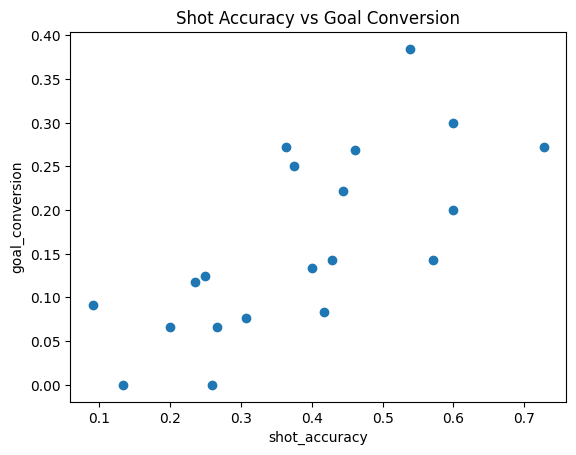

In [111]:
# Scatter plot of shooting accuracy and goal conversion rate

import matplotlib.pyplot as plt
plt.scatter( df["shot_accuracy"], df["goal_conversion"] ) 
plt.title("Shot Accuracy vs Goal Conversion")
plt.xlabel("shot_accuracy") 
plt.ylabel("goal_conversion")
plt.show()


**Scatter Plot: Shot Accuracy vs Goal Conversion**

To further explore the relationship between the engineered performance metrics, a scatter plot was created to compare shot accuracy and goal conversion rate.

Although the data points are not perfectly aligned, an overall positive trend can be observed. Teams with higher shot accuracy generally tended to achieve higher goal conversion rates.

The dispersion of the points also suggests that goal conversion is influenced by multiple factors beyond shooting accuracy, such as chance quality, goalkeeper performance, and match situations.

Findings 2:

Goal Conversion Rate and Shots per Possession showed a strong positive correlation (r = 0.90), suggesting that teams creating more shooting opportunities from possession also tended to convert chances more efficiently

Shot Accuracy was positively correlated with Goals Conversion (r = 0.71), indicating that more accurate shooting generally resulted in better finishing efficiency.

Shots per Corner showed relatively weak or negative correlations with the other engineered metrics, suggesting that corner efficiency may represent a different aspect of attacking performance.


Original match statistics such as possession and total shots describe what happened during the game, but they may not fully reflect a team's attacking efficiency. Therefore, four new performance metrics were engineered to evaluate shooting precision, finishing efficiency, attacking directness, and the effectiveness of set-piece opportunities. These features were further analysed to explore their relationships with match performance.


# Feature Correlation Analysis

After creating four new performance metrics, a correlation analysis was conducted to examine how these engineered features relate to each other.

This step helps evaluate whether the newly created metrics capture similar aspects of team performance or provide complementary information.

## Limitations

- Only 20 matches were analysed.
- The analysis focuses on home-team statistics.
- Correlation does not imply causation.
- Other tactical factors were not included.

## Future Work

Future work could include:

- analysing away-team performance

- using player-level statistics

- building a predictive machine learning model

- analysing multiple FIFA tournaments

In [112]:
#Download all the plots
import shutil

shutil.make_archive(
    "portfolio_images",
    "zip",
    "images"
)

'/kaggle/working/portfolio_images.zip'